In [ ]:
pip install pandas scikit-learn sentence-transformers

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# 1. Load data
file_path = 'dataset.csv'  # Change this to your real file name later
df = pd.read_csv(file_path)

# Drop any empty rows just in case
df = df.dropna(subset=['text', 'label'])

# 2. Encode string labels to numbers
label_encoder = LabelEncoder()
df['encoded_label'] = label_encoder.fit_transform(df['label'])

# 3. View the mapping
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Label Mapping: {mapping}")

# Display the first few rows to verify
df.head()

Label Mapping: {'complex': np.int64(0), 'simple': np.int64(1)}


,text,label,encoded_label
0,"Hey, how are you doing today?",simple,1
1,What does API stand for?,simple,1
2,Fix the typo in this sentence: 'She dont like ...,simple,1
3,Translate 'Good morning' into French.,simple,1
4,"Convert this list to a Python list: Red, Green...",simple,1


In [ ]:
model_name = 'all-MiniLM-L6-v2'
print(f"Loading Sentence Transformer: {model_name}...")
embedder = SentenceTransformer(model_name)

print("Encoding text into embeddings...")
# Convert text column to a list and encode
X = embedder.encode(df['text'].tolist(), show_progress_bar=True)
y = df['encoded_label'].values

print(f"Shape of X (Embeddings): {X.shape}")
print(f"Shape of y (Labels): {y.shape}")

Loading Sentence Transformer: all-MiniLM-L6-v2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding text into embeddings...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Shape of X (Embeddings): (200, 384)
Shape of y (Labels): (200,)


In [ ]:
# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Ensures the ratio of simple/complex stays the same in both sets
)

print(f"Training samples: {len(y_train)}")
print(f"Testing samples:  {len(y_test)}")

# 2. Initialize and train the Random Forest
print("\nTraining Random Forest...")
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

print("Training Complete!")

Training samples: 160
Testing samples:  40

Training Random Forest...
Training Complete!


In [ ]:
print("\n--- Evaluating TRAINING Data (Checking for Overfitting) ---")
y_train_pred = rf_classifier.predict(X_train)

print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred, target_names=label_encoder.classes_))
# ==========================================

# 1. Generate predictions
y_pred = rf_classifier.predict(X_test)

# 2. Calculate core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("=== Core Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

print("=== Detailed Classification Report ===")
# Pass the original string names back in for readability
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))


--- Evaluating TRAINING Data (Checking for Overfitting) ---
=== Training Classification Report ===
              precision    recall  f1-score   support

     complex       1.00      1.00      1.00        80
      simple       1.00      1.00      1.00        80

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

=== Core Metrics ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

=== Detailed Classification Report ===
              precision    recall  f1-score   support

     complex       1.00      1.00      1.00        20
      simple       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

=== Confusion Matrix ===
[[20  0]
 [ 0 20]]


In [ ]:
pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import os

def run_xgboost_pipeline(csv_file_path, text_col='text', label_col='label', model_name='all-MiniLM-L6-v2'):

    print(f"--- Step 1: Loading data from {csv_file_path} ---")
    df = pd.read_csv(csv_file_path).dropna(subset=[text_col, label_col])

    print("\n--- Step 2: Encoding Labels ---")
    # XGBoost strictly requires labels to be integers starting from 0 (e.g., 0, 1, 2...)
    # LabelEncoder handles this perfectly.
    label_encoder = LabelEncoder()
    df['encoded_label'] = label_encoder.fit_transform(df[label_col])

    mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    print(f"Label Mapping: {mapping}")

    print(f"\n--- Step 3: Loading Embedder ({model_name}) ---")
    embedder = SentenceTransformer(model_name)

    print("\n--- Step 4: Encoding text into embeddings ---")
    X = embedder.encode(df[text_col].tolist(), show_progress_bar=True)
    y = df['encoded_label'].values

    print("\n--- Step 5: Splitting data (70% Train, 30% Test) ---")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )

    print("\n--- Step 6: Training the XGBoost Classifier ---")
    # Initialize XGBoost.
    # eval_metric='logloss' suppresses a common warning in newer versions.
    xgb_classifier = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
    xgb_classifier.fit(X_train, y_train)

    # ==========================================
    # EVALUATING TRAINING DATA
    # ==========================================
    print("\n--- Step 7A: Evaluating TRAINING Data (Overfitting Check) ---")
    y_train_pred = xgb_classifier.predict(X_train)
    print("=== Training Classification Report ===")
    print(classification_report(y_train, y_train_pred, target_names=label_encoder.classes_))

    # ==========================================
    # EVALUATING TESTING DATA
    # ==========================================
    print("\n--- Step 7B: Evaluating TESTING Data (Real Performance) ---")
    y_test_pred = xgb_classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

    print("=== Core Testing Metrics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

    print("=== Testing Classification Report ===")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

    print("=== Testing Confusion Matrix ===")
    print(confusion_matrix(y_test, y_test_pred))

    return xgb_classifier, embedder, label_encoder

csv_path = 'dataset.csv'

# 2. Run the pipeline
model, embedder, encoder = run_xgboost_pipeline(csv_path)


--- Step 1: Loading data from dataset.csv ---

--- Step 2: Encoding Labels ---
Label Mapping: {'complex': np.int64(0), 'simple': np.int64(1)}

--- Step 3: Loading Embedder (all-MiniLM-L6-v2) ---


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Step 4: Encoding text into embeddings ---


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


--- Step 5: Splitting data (70% Train, 30% Test) ---

--- Step 6: Training the XGBoost Classifier ---

--- Step 7A: Evaluating TRAINING Data (Overfitting Check) ---
=== Training Classification Report ===
              precision    recall  f1-score   support

     complex       1.00      1.00      1.00        70
      simple       1.00      1.00      1.00        70

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140


--- Step 7B: Evaluating TESTING Data (Real Performance) ---
=== Core Testing Metrics ===
Accuracy:  0.9500
Precision: 0.9505
Recall:    0.9500
F1-Score:  0.9500

=== Testing Classification Report ===
              precision    recall  f1-score   support

     complex       0.94      0.97      0.95        30
      simple       0.97      0.93      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95      

--- Step 1: Loading data from dataset1.csv ---

--- Step 2: Encoding Labels ---
Label Mapping: {'complex': np.int64(0), 'simple': np.int64(1)}

--- Step 3: Loading Embedder ---


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Step 4: Encoding text into embeddings ---


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Starting 5-Fold Cross Validation...

Fold 1 | Train Acc: 1.0000, Test Acc: 1.0000 | Train F1: 1.0000, Test F1: 1.0000
Fold 2 | Train Acc: 1.0000, Test Acc: 0.9500 | Train F1: 1.0000, Test F1: 0.9499
Fold 3 | Train Acc: 1.0000, Test Acc: 0.9500 | Train F1: 1.0000, Test F1: 0.9499
Fold 4 | Train Acc: 1.0000, Test Acc: 0.9750 | Train F1: 1.0000, Test F1: 0.9750
Fold 5 | Train Acc: 1.0000, Test Acc: 1.0000 | Train F1: 1.0000, Test F1: 1.0000

=== Final Cross-Validation Results ===
Average Training Accuracy: 1.0000 (+/- 0.0000)
Average Testing Accuracy:  0.9750 (+/- 0.0224)
Average Training F1-Score: 1.0000 (+/- 0.0000)
Average Testing F1-Score:  0.9749 (+/- 0.0224)

Generating performance graphs...


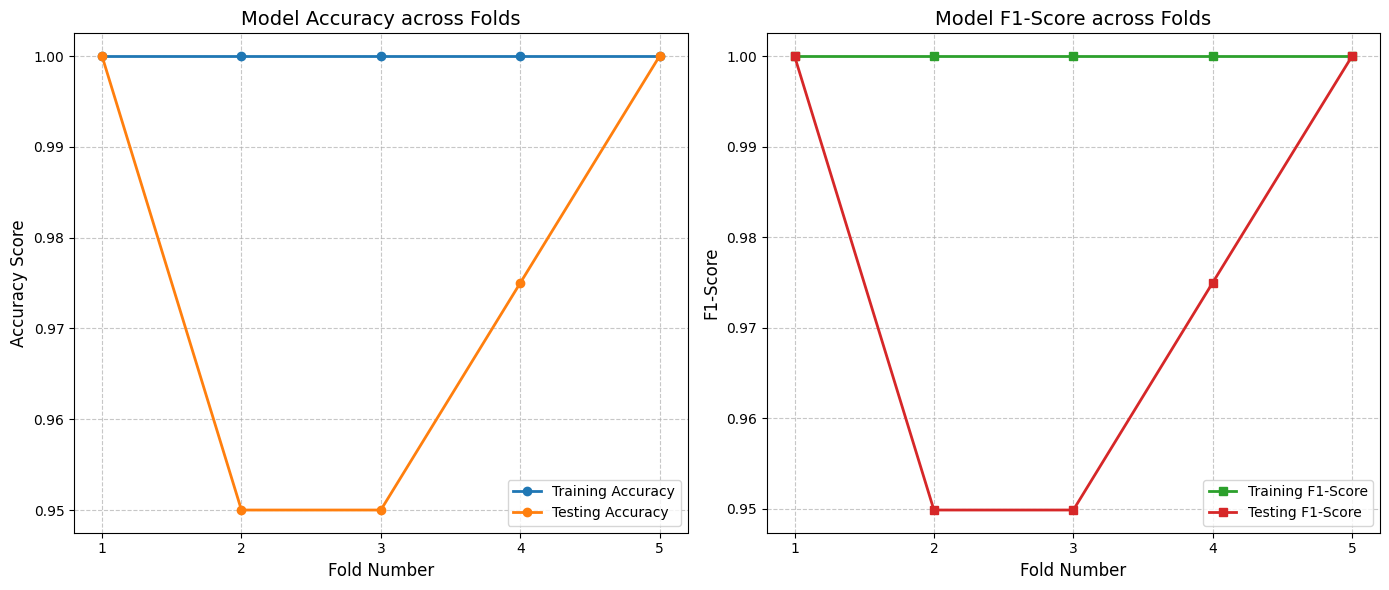

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

csv_path = 'dataset1.csv'

print(f"--- Step 1: Loading data from {csv_path} ---")
df = pd.read_csv(csv_path).dropna(subset=["text", "label"])
label_col = "label"
text_col = "text"

print("\n--- Step 2: Encoding Labels ---")
label_encoder = LabelEncoder()
df['encoded_label'] = label_encoder.fit_transform(df[label_col])

mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Label Mapping: {mapping}")

print("\n--- Step 3: Loading Embedder ---")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("\n--- Step 4: Encoding text into embeddings ---")
X = embedder.encode(df[text_col].tolist(), show_progress_bar=True)
y = df['encoded_label'].values

print("\nStarting 5-Fold Cross Validation...\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to keep track of our scores across all folds
train_accuracies = []
test_accuracies = []
train_f1_scores = []
test_f1_scores = []

# Loop through each fold
for fold_number, (train_index, test_index) in enumerate(skf.split(X, y), 1):

    # Create the train and test sets for this specific fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Initialize a fresh model
    model = XGBClassifier(n_estimators=200, learning_rate=0.2,max_depth=2, colsample_bytree=0.6, subsample=0.6, eval_metric='logloss', random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # --- EVALUATE TRAINING DATA ---
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

    # --- EVALUATE TESTING DATA ---
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

    # Save the scores to our lists
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

    print(f"Fold {fold_number} | Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} | Train F1: {train_f1:.4f}, Test F1: {test_f1:.4f}")

# Print the final averaged results
print("\n=== Final Cross-Validation Results ===")
print(f"Average Training Accuracy: {np.mean(train_accuracies):.4f} (+/- {np.std(train_accuracies):.4f})")
print(f"Average Testing Accuracy:  {np.mean(test_accuracies):.4f} (+/- {np.std(test_accuracies):.4f})")
print(f"Average Training F1-Score: {np.mean(train_f1_scores):.4f} (+/- {np.std(train_f1_scores):.4f})")
print(f"Average Testing F1-Score:  {np.mean(test_f1_scores):.4f} (+/- {np.std(test_f1_scores):.4f})")

# ==========================================
# VISUALIZATION: Plotting the Learning Curves
# ==========================================
print("\nGenerating performance graphs...")
folds = range(1, skf.n_splits + 1)

plt.figure(figsize=(14, 6))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(folds, train_accuracies, marker='o', label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(folds, test_accuracies, marker='o', label='Testing Accuracy', color='#ff7f0e', linewidth=2)
plt.title('Model Accuracy across Folds', fontsize=14)
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(folds)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: F1-Score
plt.subplot(1, 2, 2)
plt.plot(folds, train_f1_scores, marker='s', label='Training F1-Score', color='#2ca02c', linewidth=2)
plt.plot(folds, test_f1_scores, marker='s', label='Testing F1-Score', color='#d62728', linewidth=2)
plt.title('Model F1-Score across Folds', fontsize=14)
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(folds)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
# (Assuming X and y are already created from your SentenceTransformer step)

print("--- Setting up Hyperparameter Tuning ---")

# 1. Initialize a blank XGBoost model
base_model = XGBClassifier(eval_metric='logloss', random_state=42)

# 2. Define the "Search Space" (The parameters you want to test)
# The pipeline will mix and match these values to find the best combo
param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # How fast it learns
    'max_depth': [2, 3, 5, 7],                # Tree depth (lower prevents overfitting)
    'n_estimators': [50, 100, 150, 200],      # Number of trees
    'subsample': [0.6, 0.8, 1.0],             # Row sampling %
    'colsample_bytree': [0.6, 0.8, 1.0]       # Feature sampling %
}

# 3. Set up your 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Initialize the Randomized Search
# This is the "manager" that runs the tests
tuner = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=20,                 # How many random combinations to test (increase if you have time!)
    scoring='f1_weighted',     # We want it to find the best F1-Score
    cv=skf,                    # Use the 5 folds for testing every combination
    verbose=1,                 # Print progress to the console
    random_state=42,
    n_jobs=-1                  # Use all your computer's CPU cores to go faster
)

print("\nStarting the search... (This might take a minute depending on your CPU)")
tuner.fit(X, y)

# 5. Extract the Results
print("\n=== Tuning Complete! ===")
print(f"Best Cross-Validation F1-Score: {tuner.best_score_:.4f}")
print("\nHere are the exact parameters that got this score:")
for param_name, best_value in tuner.best_params_.items():
    print(f"  - {param_name}: {best_value}")

# 6. Save the ultimate winning model
best_xgb_model = tuner.best_estimator_

# You can now use `best_xgb_model` to predict on new data!
# e.g., best_xgb_model.predict(new_embeddings)

--- Setting up Hyperparameter Tuning ---

Starting the search... (This might take a minute depending on your CPU)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Tuning Complete! ===
Best Cross-Validation F1-Score: 0.9749

Here are the exact parameters that got this score:
  - subsample: 0.6
  - n_estimators: 200
  - max_depth: 2
  - learning_rate: 0.2
  - colsample_bytree: 0.6


In [ ]:
pip install torch


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ==========================================
# 1. Define the 7-Layer Deep Neural Network
# ==========================================
class DeepTextClassifier(nn.Module):
    def __init__(self, input_dim=384, num_classes=2):
        super(DeepTextClassifier, self).__init__()

        # 7-Layer Architecture with Dropout to prevent overfitting
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), # Drops 50% of connections randomly to force generalization

            # Layer 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            # Layer 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 4
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 5
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Layer 6
            nn.Linear(32, 16),
            nn.ReLU(),

            # Layer 7 (Output)
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# ==========================================
# 2. Prepare Data for PyTorch
# ==========================================
def prepare_dataloaders(X_train, X_test, y_train, y_test, batch_size=16):
    # Convert NumPy arrays to PyTorch Tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # Create TensorDatasets
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    # Create DataLoaders (handles batching and shuffling automatically)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# ==========================================
# 3. The Training & Evaluation Loop
# ==========================================
def train_and_evaluate_model(model, train_loader, test_loader, epochs=50, lr=0.001):
    # Use GPU if available, otherwise CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Loss function and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4) # AdamW helps with regularization

    # Tracking metrics
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    print(f"Training on device: {device}")
    print("Starting Training...\n")

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train() # Set model to training mode (enables Dropout)
        train_loss, train_preds, train_targets = 0.0, [], []

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()           # Clear old gradients
            outputs = model(batch_X)        # Forward pass
            loss = criterion(outputs, batch_y) # Calculate loss
            loss.backward()                 # Backward pass
            optimizer.step()                # Update weights

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())

        train_acc = accuracy_score(train_targets, train_preds)

        # --- TESTING PHASE ---
        model.eval() # Set model to evaluation mode (disables Dropout)
        test_loss, test_preds, test_targets = 0.0, [], []

        with torch.no_grad(): # Don't track gradients during testing
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                test_preds.extend(predicted.cpu().numpy())
                test_targets.extend(batch_y.cpu().numpy())

        test_acc = accuracy_score(test_targets, test_preds)

        # Save metrics for this epoch
        history['train_loss'].append(train_loss / len(train_loader))
        history['test_loss'].append(test_loss / len(test_loader))
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | "
                  f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f}, Test Loss: {history['test_loss'][-1]:.4f}")

    return model, history

# ==========================================
# Execution Block
# ==========================================
if __name__ == "__main__":
    # 1. Create a dummy CSV file to test
    csv_path = 'dataset.csv'

    # 2. Load and Encode Data
    df = pd.read_csv(csv_path)
    label_encoder = LabelEncoder()
    df['encoded_label'] = label_encoder.fit_transform(df['label'])

    # 3. Generate Embeddings
    print("Loading Embedder...")
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    X = embedder.encode(df['text'].tolist(), show_progress_bar=False)
    y = df['encoded_label'].values

    # 4. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 5. Prepare PyTorch DataLoaders
    train_loader, test_loader = prepare_dataloaders(X_train, X_test, y_train, y_test, batch_size=16)

    # 6. Initialize Model
    # input_dim=384 (from SentenceTransformers), num_classes=2 ("simple" vs "complex")
    model = DeepTextClassifier(input_dim=384, num_classes=len(label_encoder.classes_))

    # 7. Train and Evaluate
    trained_model, history = train_and_evaluate_model(model, train_loader, test_loader, epochs=50)

    # 8. Plot the Learning Curves
    epochs_range = range(1, 51)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue')
    plt.plot(epochs_range, history['test_acc'], label='Test Accuracy', color='orange')
    plt.title('PyTorch Model Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='orange')
    plt.title('PyTorch Model Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Cross Entropy)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Loading Embedder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training on device: cpu
Starting Training...

Epoch [1/50] | Train Acc: 0.6500, Test Acc: 0.8167 | Train Loss: 0.5788, Test Loss: 0.6719
Epoch [10/50] | Train Acc: 1.0000, Test Acc: 0.9167 | Train Loss: 0.0201, Test Loss: 0.2194
Epoch [20/50] | Train Acc: 1.0000, Test Acc: 0.9000 | Train Loss: 0.0072, Test Loss: 0.2365
Epoch [30/50] | Train Acc: 1.0000, Test Acc: 0.9167 | Train Loss: 0.0030, Test Loss: 0.2397
Epoch [40/50] | Train Acc: 1.0000, Test Acc: 0.9167 | Train Loss: 0.0029, Test Loss: 0.2411
Epoch [50/50] | Train Acc: 1.0000, Test Acc: 0.9000 | Train Loss: 0.0023, Test Loss: 0.2515


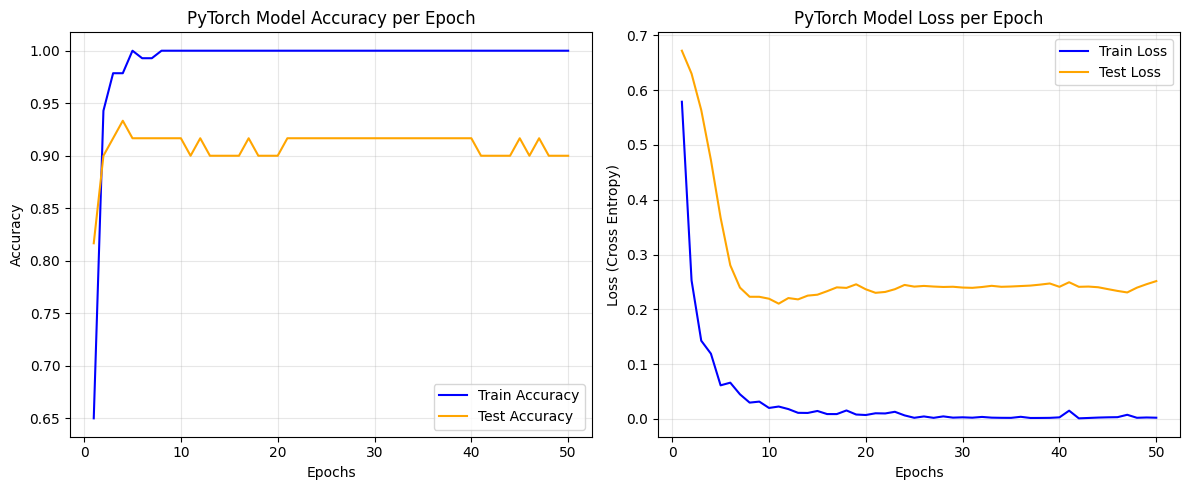

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ==========================================
# 1. Define the 2-Layer Deep Neural Network
# ==========================================
class DeepTextClassifier(nn.Module):
    def __init__(self, input_dim=384, num_classes=2):
        super(DeepTextClassifier, self).__init__()

        # 2-Layer Architecture: 1 Hidden Layer, 1 Output Layer
        self.network = nn.Sequential(
            # Layer 1 (Hidden Layer)
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2 (Output Layer)
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# ==========================================
# 2. Prepare Data for PyTorch
# ==========================================
def prepare_dataloaders(X_train, X_test, y_train, y_test, batch_size=16):
    # Convert NumPy arrays to PyTorch Tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # Create TensorDatasets
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    # Create DataLoaders (handles batching and shuffling automatically)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# ==========================================
# 3. The Training & Evaluation Loop
# ==========================================
def train_and_evaluate_model(model, train_loader, test_loader, epochs=50, lr=0.001):
    # Use GPU if available, otherwise CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Loss function and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4) # AdamW helps with regularization

    # Tracking metrics
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    print(f"Training on device: {device}")
    print("Starting Training...\n")

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train() # Set model to training mode (enables Dropout)
        train_loss, train_preds, train_targets = 0.0, [], []

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()           # Clear old gradients
            outputs = model(batch_X)        # Forward pass
            loss = criterion(outputs, batch_y) # Calculate loss
            loss.backward()                 # Backward pass
            optimizer.step()                # Update weights

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())

        train_acc = accuracy_score(train_targets, train_preds)

        # --- TESTING PHASE ---
        model.eval() # Set model to evaluation mode (disables Dropout)
        test_loss, test_preds, test_targets = 0.0, [], []

        with torch.no_grad(): # Don't track gradients during testing
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                test_preds.extend(predicted.cpu().numpy())
                test_targets.extend(batch_y.cpu().numpy())

        test_acc = accuracy_score(test_targets, test_preds)

        # Save metrics for this epoch
        history['train_loss'].append(train_loss / len(train_loader))
        history['test_loss'].append(test_loss / len(test_loader))
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | "
                  f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f}, Test Loss: {history['test_loss'][-1]:.4f}")

    return model, history

# ==========================================
# Execution Block
# ==========================================
if __name__ == "__main__":
    # 1. Create a dummy CSV file to test
    csv_path = 'dataset.csv'

    # 2. Load and Encode Data
    df = pd.read_csv(csv_path)
    label_encoder = LabelEncoder()
    df['encoded_label'] = label_encoder.fit_transform(df['label'])

    # 3. Generate Embeddings
    print("Loading Embedder...")
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    X = embedder.encode(df['text'].tolist(), show_progress_bar=False)
    y = df['encoded_label'].values

    # 4. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 5. Prepare PyTorch DataLoaders
    train_loader, test_loader = prepare_dataloaders(X_train, X_test, y_train, y_test, batch_size=16)

    # 6. Initialize Model
    # input_dim=384 (from SentenceTransformers), num_classes=2 ("simple" vs "complex")
    model = DeepTextClassifier(input_dim=384, num_classes=len(label_encoder.classes_))

    # 7. Train and Evaluate
    trained_model, history = train_and_evaluate_model(model, train_loader, test_loader, epochs=50)

    # 8. Plot the Learning Curves
    epochs_range = range(1, 51)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue')
    plt.plot(epochs_range, history['test_acc'], label='Test Accuracy', color='orange')
    plt.title('PyTorch Model Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='orange')
    plt.title('PyTorch Model Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Cross Entropy)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

# 1. Download required NLTK dictionary data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Added to resolve LookupError

# 2. Load your dataset
csv_path = 'dataset.csv'
df = pd.read_csv(csv_path)

# 3. Initialize the NLTK tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase the text
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize (split into words)
    tokens = word_tokenize(text)

    # Remove stopwords and Lemmatize
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]

    # Join the words back into a single string
    return " ".join(processed_tokens)

# 4. Apply the cleaning function to create a new column
print("Cleaning text data...")
df['processed_text'] = df['text'].apply(clean_text)

# Show a before-and-after comparison
print("\n--- Before vs After ---")
print(df[['text', 'processed_text']].head(5))

# Save the newly processed data to a new CSV file
df.to_csv('cleaned_dataset.csv', index=False)
print("\nSaved to 'cleaned_dataset.csv'")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Cleaning text data...

--- Before vs After ---
                                                text  \
0                      Hey, how are you doing today?   
1                           What does API stand for?   
2  Fix the typo in this sentence: 'She dont like ...   
3              Translate 'Good morning' into French.   
4  Convert this list to a Python list: Red, Green...   

                            processed_text  
0                                hey today  
1                                api stand  
2        fix typo sentence dont like apple  
3            translate good morning french  
4  convert list python list red green blue  

Saved to 'cleaned_dataset.csv'


Loading Embedder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training on device: cpu
Starting Training...

Epoch [1/50] | Train Acc: 0.6857, Test Acc: 0.8833 | Train Loss: 0.5745, Test Loss: 0.6680
Epoch [10/50] | Train Acc: 1.0000, Test Acc: 0.9000 | Train Loss: 0.0169, Test Loss: 0.2164
Epoch [20/50] | Train Acc: 1.0000, Test Acc: 0.9333 | Train Loss: 0.0048, Test Loss: 0.2268
Epoch [30/50] | Train Acc: 1.0000, Test Acc: 0.9333 | Train Loss: 0.0037, Test Loss: 0.2322
Epoch [40/50] | Train Acc: 1.0000, Test Acc: 0.9167 | Train Loss: 0.0032, Test Loss: 0.2380
Epoch [50/50] | Train Acc: 1.0000, Test Acc: 0.9333 | Train Loss: 0.0012, Test Loss: 0.2426


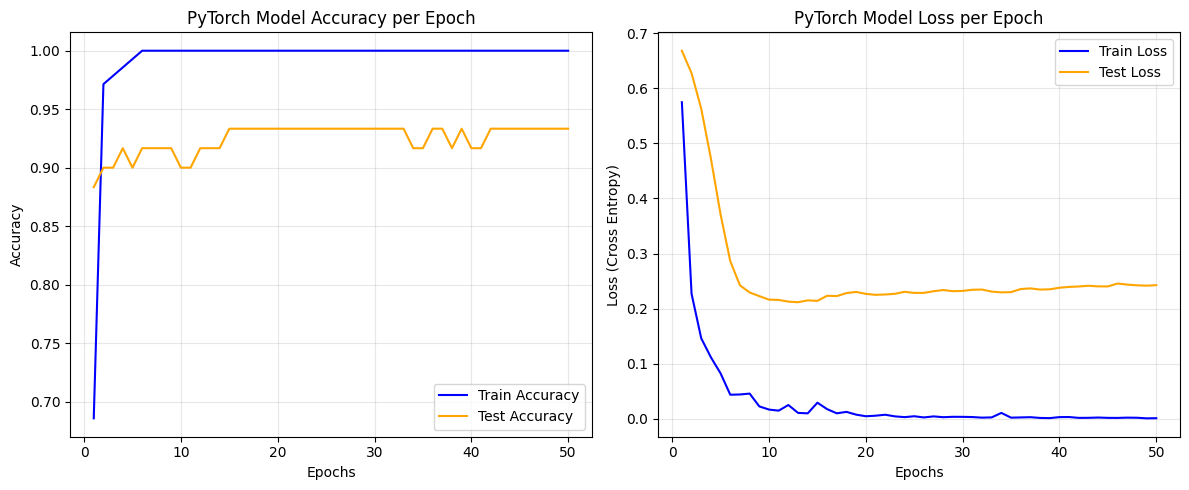

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ==========================================
# 1. Define the 2-Layer Deep Neural Network
# ==========================================
class DeepTextClassifier(nn.Module):
    def __init__(self, input_dim=384, num_classes=2):
        super(DeepTextClassifier, self).__init__()

        # 2-Layer Architecture: 1 Hidden Layer, 1 Output Layer
        self.network = nn.Sequential(
            # Layer 1 (Hidden Layer)
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2 (Output Layer)
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# ==========================================
# 2. Prepare Data for PyTorch
# ==========================================
def prepare_dataloaders(X_train, X_test, y_train, y_test, batch_size=16):
    # Convert NumPy arrays to PyTorch Tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # Create TensorDatasets
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    # Create DataLoaders (handles batching and shuffling automatically)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# ==========================================
# 3. The Training & Evaluation Loop
# ==========================================
def train_and_evaluate_model(model, train_loader, test_loader, epochs=50, lr=0.001):
    # Use GPU if available, otherwise CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Loss function and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4) # AdamW helps with regularization

    # Tracking metrics
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    print(f"Training on device: {device}")
    print("Starting Training...\n")

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train() # Set model to training mode (enables Dropout)
        train_loss, train_preds, train_targets = 0.0, [], []

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()           # Clear old gradients
            outputs = model(batch_X)        # Forward pass
            loss = criterion(outputs, batch_y) # Calculate loss
            loss.backward()                 # Backward pass
            optimizer.step()                # Update weights

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())

        train_acc = accuracy_score(train_targets, train_preds)

        # --- TESTING PHASE ---
        model.eval() # Set model to evaluation mode (disables Dropout)
        test_loss, test_preds, test_targets = 0.0, [], []

        with torch.no_grad(): # Don't track gradients during testing
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                test_preds.extend(predicted.cpu().numpy())
                test_targets.extend(batch_y.cpu().numpy())

        test_acc = accuracy_score(test_targets, test_preds)

        # Save metrics for this epoch
        history['train_loss'].append(train_loss / len(train_loader))
        history['test_loss'].append(test_loss / len(test_loader))
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | "
                  f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f}, Test Loss: {history['test_loss'][-1]:.4f}")

    return model, history

# ==========================================
# Execution Block
# ==========================================
if __name__ == "__main__":
    # 1. Create a dummy CSV file to test
    csv_path = 'cleaned_dataset.csv'

    # 2. Load and Encode Data
    df = pd.read_csv(csv_path)
    label_encoder = LabelEncoder()
    df['encoded_label'] = label_encoder.fit_transform(df['label'])

    # 3. Generate Embeddings
    print("Loading Embedder...")
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    X = embedder.encode(df['text'].tolist(), show_progress_bar=False)
    y = df['encoded_label'].values

    # 4. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # 5. Prepare PyTorch DataLoaders
    train_loader, test_loader = prepare_dataloaders(X_train, X_test, y_train, y_test, batch_size=16)

    # 6. Initialize Model
    # input_dim=384 (from SentenceTransformers), num_classes=2 ("simple" vs "complex")
    model = DeepTextClassifier(input_dim=384, num_classes=len(label_encoder.classes_))

    # 7. Train and Evaluate
    trained_model, history = train_and_evaluate_model(model, train_loader, test_loader, epochs=50)

    # 8. Plot the Learning Curves
    epochs_range = range(1, 51)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue')
    plt.plot(epochs_range, history['test_acc'], label='Test Accuracy', color='orange')
    plt.title('PyTorch Model Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
    plt.plot(epochs_range, history['test_loss'], label='Test Loss', color='orange')
    plt.title('PyTorch Model Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Cross Entropy)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [18]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. Load and Prepare Data
# ==========================================
# Note: Using the 'cleaned_dataset.csv' created in the previous step
csv_path = 'cleaned_dataset.csv'
try:
    df = pd.read_csv(csv_path)
except FileNotFoundError:
    # Fallback to the original if the cleaned one isn't found
    df = pd.read_csv('intent_classification_dataset (1).csv')
    df['processed_text'] = df['text']

# Drop missing values just in case
df = df.dropna(subset=['processed_text', 'label'])

# Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

# ==========================================
# 2. Generate Embeddings
# ==========================================
print("Generating Embeddings...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# We use the processed text to avoid overfitting on noisy words (stopwords/punctuation)
X = embedder.encode(df['processed_text'].tolist(), show_progress_bar=True)

# ==========================================
# 3. Train/Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(y_train)} samples")
print(f"Testing set size: {len(y_test)} samples\n")

# ==========================================
# 4. Model 1: Logistic Regression
# ==========================================
print("--- Training Logistic Regression ---")
# class_weight='balanced' helps if you have more of one intent than the other
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# Evaluate Logistic Regression
lr_train_preds = log_reg.predict(X_train)
lr_test_preds = log_reg.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, lr_train_preds):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, lr_test_preds):.4f}\n")
print("Classification Report (Test Data):")
print(classification_report(y_test, lr_test_preds, target_names=label_encoder.classes_))

# ==========================================
# 5. Model 2: Support Vector Machine (SVM)
# ==========================================
print("\n--- Training Support Vector Machine (SVM) ---")
# 'linear' kernel is almost always the best choice for text classification/embeddings
# C=1.0 is the regularization parameter. Lower C = more regularization (prevents overfitting)
svm_model = SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)

# Evaluate SVM
svm_train_preds = svm_model.predict(X_train)
svm_test_preds = svm_model.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, svm_train_preds):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, svm_test_preds):.4f}\n")
print("Classification Report (Test Data):")
print(classification_report(y_test, svm_test_preds, target_names=label_encoder.classes_))

Generating Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Training set size: 140 samples
Testing set size: 60 samples

--- Training Logistic Regression ---
Train Accuracy: 0.9857
Test Accuracy:  0.9000

Classification Report (Test Data):
              precision    recall  f1-score   support

     complex       0.93      0.87      0.90        30
      simple       0.88      0.93      0.90        30

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60


--- Training Support Vector Machine (SVM) ---
Train Accuracy: 1.0000
Test Accuracy:  0.9333

Classification Report (Test Data):
              precision    recall  f1-score   support

     complex       0.93      0.93      0.93        30
      simple       0.93      0.93      0.93        30

    accuracy                           0.93        60
   macro avg       0.93      0.93      0.93        60
weighted avg       0.93      0.93      0.93        60



In [19]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings

# Ignore convergence warnings during grid search for cleaner output
warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Data & Generate Embeddings
# ==========================================
# Try loading the cleaned dataset first, fallback to the original
try:
    df = pd.read_csv('cleaned_dataset.csv')
    text_column = 'processed_text'
except FileNotFoundError:
    df = pd.read_csv('intent_classification_dataset (1).csv')
    text_column = 'text'

# Drop missing values
df = df.dropna(subset=[text_column, 'label'])

# Encode Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

print("Generating Embeddings...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
X = embedder.encode(df[text_column].tolist(), show_progress_bar=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==========================================
# 2. Define the Hyperparameter Grid
# ==========================================
# We are testing 30 different combinations (5 x 2 x 3)
param_grid = {
    # C is Inverse of regularization strength. Smaller values specify stronger regularization.
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],

    # Class weight helps if you have imbalanced data
    'class_weight': ['balanced', None],

    # The optimization algorithm
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# ==========================================
# 3. Run Grid Search with Cross-Validation
# ==========================================
print("\nStarting Grid Search for Logistic Regression...")
base_model = LogisticRegression(max_iter=1000, random_state=42)

# cv=5 means 5-fold cross validation. It splits the training set into 5 parts,
# trains on 4, and validates on 1, rotating until all parts are validated.
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # Uses all available CPU cores
    verbose=1   # Prints progress
)

grid_search.fit(X_train, y_train)

# ==========================================
# 4. Results & Evaluation
# ==========================================
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# The grid_search automatically retrains the best model on the entire training set
best_model = grid_search.best_estimator_

# Evaluate on the unseen Test Set
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

print(f"\nFinal Train Accuracy: {accuracy_score(y_train, train_preds):.4f}")
print(f"Final Test Accuracy:  {accuracy_score(y_test, test_preds):.4f}\n")

print("Classification Report on Test Data:")
print(classification_report(y_test, test_preds, target_names=label_encoder.classes_))

Generating Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Starting Grid Search for Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

--- Grid Search Results ---
Best Parameters Found: {'C': 10.0, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.9429

Final Train Accuracy: 1.0000
Final Test Accuracy:  0.9000

Classification Report on Test Data:
              precision    recall  f1-score   support

     complex       0.93      0.87      0.90        30
      simple       0.88      0.93      0.90        30

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



In [20]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import warnings

# Ignore convergence warnings during grid search for cleaner output
warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Data & Generate Embeddings
# ==========================================
try:
    df = pd.read_csv('cleaned_dataset.csv')
    text_column = 'processed_text'
except FileNotFoundError:
    df = pd.read_csv('intent_classification_dataset (1).csv')
    text_column = 'text'

df = df.dropna(subset=[text_column, 'label'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

print("Generating Embeddings...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
X = embedder.encode(df[text_column].tolist(), show_progress_bar=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==========================================
# 2. Define the UPDATED Hyperparameter Grid
# ==========================================
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'class_weight': ['balanced', None],
    'solver': ['liblinear', 'lbfgs', 'saga'],

    # NEW: Tuning max iterations
    # 100 is default, 500-2000 gives complex solvers more time to find the minimum error
    'max_iter': [100, 500, 1000, 2000]
}

# ==========================================
# 3. Run Grid Search
# ==========================================
print("\nStarting Grid Search for Logistic Regression (with max_iter)...")
# Note: max_iter is removed from here since the grid will supply it
base_model = LogisticRegression(random_state=42)

# cv=5 means 5-fold cross validation.
# n_jobs=-1 uses all CPU cores to speed up the massive number of combinations.
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# ==========================================
# 4. Results & Evaluation
# ==========================================
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# The grid_search automatically retrains the best model on the entire training set
best_model = grid_search.best_estimator_

# Evaluate on the unseen Test Set
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

print(f"\nFinal Train Accuracy: {accuracy_score(y_train, train_preds):.4f}")
print(f"Final Test Accuracy:  {accuracy_score(y_test, test_preds):.4f}\n")

print("Classification Report on Test Data:")
print(classification_report(y_test, test_preds, target_names=label_encoder.classes_))

Generating Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Starting Grid Search for Logistic Regression (with max_iter)...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

--- Grid Search Results ---
Best Parameters Found: {'C': 10.0, 'class_weight': 'balanced', 'max_iter': 100, 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.9429

Final Train Accuracy: 1.0000
Final Test Accuracy:  0.9000

Classification Report on Test Data:
              precision    recall  f1-score   support

     complex       0.93      0.87      0.90        30
      simple       0.88      0.93      0.90        30

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



In [22]:
# ==========================================
# Model 1: Nearest Centroid Classifier
# ==========================================
print("\n--- Training Nearest Centroid ---")
# Changed to 'euclidean'. Because SentenceTransformer embeddings are normalized,
# Euclidean distance behaves identically to Cosine similarity here!
nc_model = NearestCentroid(metric='euclidean')
nc_model.fit(X_train, y_train)

nc_train_preds = nc_model.predict(X_train)
nc_test_preds = nc_model.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, nc_train_preds):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, nc_test_preds):.4f}\n")
print(classification_report(y_test, nc_test_preds, target_names=label_encoder.classes_))

# ==========================================
# Model 2: K-Nearest Neighbors (KNN)
# ==========================================
print("\n--- Training K-Nearest Neighbors (KNN) ---")
# KNN still happily accepts 'cosine', so we can leave this one as is!
knn_model = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_model.fit(X_train, y_train)

knn_train_preds = knn_model.predict(X_train)
knn_test_preds = knn_model.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, knn_train_preds):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, knn_test_preds):.4f}\n")
print(classification_report(y_test, knn_test_preds, target_names=label_encoder.classes_))


--- Training Nearest Centroid ---
Train Accuracy: 0.9571
Test Accuracy:  0.9000

              precision    recall  f1-score   support

     complex       0.96      0.83      0.89        30
      simple       0.85      0.97      0.91        30

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60


--- Training K-Nearest Neighbors (KNN) ---
Train Accuracy: 0.9429
Test Accuracy:  0.9167

              precision    recall  f1-score   support

     complex       0.93      0.90      0.92        30
      simple       0.90      0.93      0.92        30

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60



In [25]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings

# Ignore warnings for a cleaner output
warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Data & Generate Embeddings
# ==========================================
try:
    df = pd.read_csv('cleaned_dataset.csv')
    text_column = 'processed_text'
except FileNotFoundError:
    df = pd.read_csv('intent_classification_dataset (1).csv')
    text_column = 'text'

df = df.dropna(subset=[text_column, 'label'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

print("Generating Embeddings...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
X = embedder.encode(df[text_column].tolist(), show_progress_bar=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==========================================
# 2. Define the Hyperparameter Grid for KNN
# ==========================================
param_grid = {
    # The number of neighbors to vote on the classification
    'n_neighbors': [1, 2,3,4, 5,6, 7, 8,9, 11, 15],

    # How much say each neighbor has
    'weights': ['uniform', 'distance'],

    # How we measure the distance between sentences
    'metric': ['cosine', 'euclidean']
}

# ==========================================
# 3. Run Grid Search
# ==========================================
print("\nStarting Grid Search for K-Nearest Neighbors...")
base_model = KNeighborsClassifier()

# cv=5 (5-fold cross-validation), n_jobs=-1 (use all CPU cores)
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# ==========================================
# 4. Results & Evaluation
# ==========================================
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# The grid_search automatically retrains the best model on the entire training set
best_model = grid_search.best_estimator_

# Evaluate on the unseen Test Set
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

print(f"\nFinal Train Accuracy: {accuracy_score(y_train, train_preds):.4f}")
print(f"Final Test Accuracy:  {accuracy_score(y_test, test_preds):.4f}\n")

print("Classification Report on Test Data:")
print(classification_report(y_test, test_preds, target_names=label_encoder.classes_))

Generating Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Starting Grid Search for K-Nearest Neighbors...
Fitting 5 folds for each of 44 candidates, totalling 220 fits

--- Grid Search Results ---
Best Parameters Found: {'metric': 'cosine', 'n_neighbors': 1, 'weights': 'uniform'}
Best Cross-Validation Accuracy: 0.9214

Final Train Accuracy: 1.0000
Final Test Accuracy:  0.8667

Classification Report on Test Data:
              precision    recall  f1-score   support

     complex       0.87      0.87      0.87        30
      simple       0.87      0.87      0.87        30

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



In [26]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import accuracy_score, classification_report
import warnings

# Ignore warnings for a cleaner output
warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Data & Generate Embeddings
# ==========================================
try:
    df = pd.read_csv('cleaned_dataset.csv')
    text_column = 'processed_text'
except FileNotFoundError:
    df = pd.read_csv('intent_classification_dataset (1).csv')
    text_column = 'text'

df = df.dropna(subset=[text_column, 'label'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

print("Generating Embeddings...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
X = embedder.encode(df[text_column].tolist(), show_progress_bar=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==========================================
# 2. Define the Hyperparameter Grid for Nearest Centroid
# ==========================================
param_grid = {
    # The distance metric to use
    'metric': ['euclidean', 'manhattan'],

    # Shrink threshold for regularization (None means no shrinking)
    # We test various numbers to see if dropping noisy dimensions helps
    'shrink_threshold': [None, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

# ==========================================
# 3. Run Grid Search
# ==========================================
print("\nStarting Grid Search for Nearest Centroid...")
base_model = NearestCentroid()

# cv=5 (5-fold cross-validation), n_jobs=-1 (use all CPU cores)
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# ==========================================
# 4. Results & Evaluation
# ==========================================
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# The grid_search automatically retrains the best model on the entire training set
best_model = grid_search.best_estimator_

# Evaluate on the unseen Test Set
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

print(f"\nFinal Train Accuracy: {accuracy_score(y_train, train_preds):.4f}")
print(f"Final Test Accuracy:  {accuracy_score(y_test, test_preds):.4f}\n")

print("Classification Report on Test Data:")
print(classification_report(y_test, test_preds, target_names=label_encoder.classes_))

Generating Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Starting Grid Search for Nearest Centroid...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- Grid Search Results ---
Best Parameters Found: {'metric': 'euclidean', 'shrink_threshold': None}
Best Cross-Validation Accuracy: 0.9286

Final Train Accuracy: 0.9571
Final Test Accuracy:  0.9000

Classification Report on Test Data:
              precision    recall  f1-score   support

     complex       0.96      0.83      0.89        30
      simple       0.85      0.97      0.91        30

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60



Generating Embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Starting Grid Search for Nearest Centroid...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- Grid Search Results ---
Best Parameters Found: {'metric': 'euclidean', 'shrink_threshold': None}
Best Cross-Validation Accuracy: 0.9286

Final Train Accuracy: 0.9571
Final Test Accuracy:  0.9000

Classification Report on Test Data:
              precision    recall  f1-score   support

     complex       0.96      0.83      0.89        30
      simple       0.85      0.97      0.91        30

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60


Generating Hyperparameter Graph...


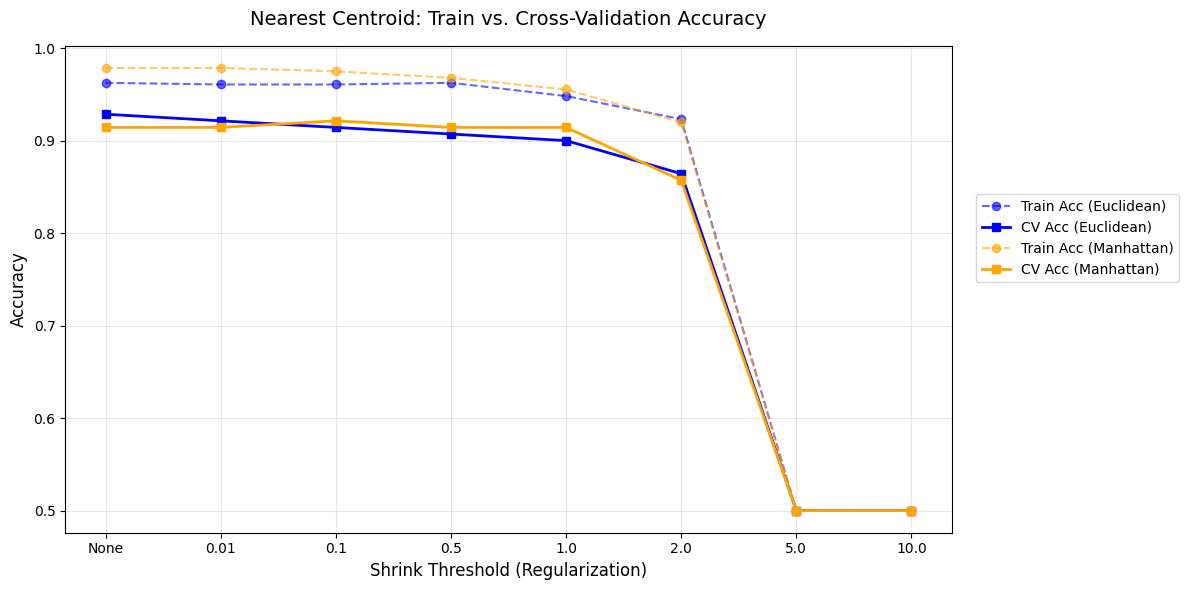

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import accuracy_score, classification_report
import warnings

# Ignore warnings for a cleaner output
warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Data & Generate Embeddings
# ==========================================
try:
    df = pd.read_csv('cleaned_dataset.csv')
    text_column = 'processed_text'
except FileNotFoundError:
    df = pd.read_csv('intent_classification_dataset (1).csv')
    text_column = 'text'

df = df.dropna(subset=[text_column, 'label'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

print("Generating Embeddings...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
X = embedder.encode(df[text_column].tolist(), show_progress_bar=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ==========================================
# 2. Define the Hyperparameter Grid for Nearest Centroid
# ==========================================
param_grid = {
    'metric': ['euclidean', 'manhattan'],
    'shrink_threshold': [None, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

# ==========================================
# 3. Run Grid Search (Added return_train_score=True)
# ==========================================
print("\nStarting Grid Search for Nearest Centroid...")
base_model = NearestCentroid()

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True # <--- CRITICAL ADDITION FOR PLOTTING
)

grid_search.fit(X_train, y_train)

# ==========================================
# 4. Results & Evaluation
# ==========================================
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

print(f"\nFinal Train Accuracy: {accuracy_score(y_train, train_preds):.4f}")
print(f"Final Test Accuracy:  {accuracy_score(y_test, test_preds):.4f}\n")

print("Classification Report on Test Data:")
print(classification_report(y_test, test_preds, target_names=label_encoder.classes_))


# ==========================================
# 5. Plotting Train vs. CV Accuracy
# ==========================================
print("\nGenerating Hyperparameter Graph...")

# Extract results into a DataFrame for easy handling
results = pd.DataFrame(grid_search.cv_results_)

# Convert 'None' to a string 'None' so matplotlib can plot it on the x-axis alongside numbers
results['param_shrink_threshold'] = results['param_shrink_threshold'].fillna('None').astype(str)

plt.figure(figsize=(12, 6))

# --- Plot for Euclidean Metric ---
euclidean_df = results[results['param_metric'] == 'euclidean']
plt.plot(euclidean_df['param_shrink_threshold'], euclidean_df['mean_train_score'],
         marker='o', linestyle='--', color='blue', alpha=0.6, label='Train Acc (Euclidean)')
plt.plot(euclidean_df['param_shrink_threshold'], euclidean_df['mean_test_score'],
         marker='s', linestyle='-', color='blue', linewidth=2, label='CV Acc (Euclidean)')

# --- Plot for Manhattan Metric ---
manhattan_df = results[results['param_metric'] == 'manhattan']
plt.plot(manhattan_df['param_shrink_threshold'], manhattan_df['mean_train_score'],
         marker='o', linestyle='--', color='orange', alpha=0.6, label='Train Acc (Manhattan)')
plt.plot(manhattan_df['param_shrink_threshold'], manhattan_df['mean_test_score'],
         marker='s', linestyle='-', color='orange', linewidth=2, label='CV Acc (Manhattan)')

# Formatting the graph
plt.title('Nearest Centroid: Train vs. Cross-Validation Accuracy', fontsize=14, pad=15)
plt.xlabel('Shrink Threshold (Regularization)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower left', bbox_to_anchor=(1.02, 0.5)) # Puts legend outside to avoid blocking lines
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

In [29]:
import numpy as np

def predict_intents_sklearn(new_texts, trained_model, embedder, encoder):
    """
    Predicts the intent of new sentences using a Scikit-Learn model.
    """
    # 1. Preprocess the text (Use the same function from your training script!)
    cleaned_texts = [clean_text(text) for text in new_texts]

    # 2. Generate Embeddings
    print("Generating embeddings for new text...")
    embeddings = embedder.encode(cleaned_texts, show_progress_bar=False)

    # 3. Make Predictions
    numerical_predictions = trained_model.predict(embeddings)

    # 4. Decode predictions back to original strings ("simple" or "complex")
    string_labels = encoder.inverse_transform(numerical_predictions)

    # Print results nicely
    print("\n--- Prediction Results ---")
    for original_text, label in zip(new_texts, string_labels):
        print(f"[{label.upper()}] : {original_text}")

    return string_labels

# ==========================================
# Example Usage:
# ==========================================
# Put some brand new sentences here that the model has never seen
unseen_sentences = [
    "How do I print a string in Python?",
    "Architect a fully redundant microservices backend for a fintech app using AWS Kubernetes and cross-region failover.",
    "Fix the spelling mistake in this document.",
    "Develop a comprehensive 6-month marketing strategy for a B2B SaaS launch including KPI tracking and budget allocation."
]

# Assuming 'best_model', 'embedder', and 'label_encoder' are still in your memory from the previous script:
predictions = predict_intents_sklearn(unseen_sentences, best_model, embedder, label_encoder)

Generating embeddings for new text...

--- Prediction Results ---
[SIMPLE] : How do I print a string in Python?
[COMPLEX] : Architect a fully redundant microservices backend for a fintech app using AWS Kubernetes and cross-region failover.
[SIMPLE] : Fix the spelling mistake in this document.
[COMPLEX] : Develop a comprehensive 6-month marketing strategy for a B2B SaaS launch including KPI tracking and budget allocation.


In [30]:
import joblib

# Save the trained model
joblib.dump(best_model, 'intent_classification_model.pkl')

# Save the label encoder
joblib.dump(label_encoder, 'intent_label_encoder.pkl')

print("Model and Encoder successfully saved!")

Model and Encoder successfully saved!
